<div style="background:linear-gradient(135deg,#1a2980 0%,#26d0ce 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🌊&nbsp; Solving Burgers' Equation with a PINN</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">A complete, from-scratch walkthrough of a Physics-Informed Neural Network (PINN): we encode the viscous Burgers PDE directly into the loss function and let gradient descent discover a solution that obeys physics — no meshing, no labelled data.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">beginner</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">PINN · forward problem</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">PDE</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">Burgers (1D, viscous)</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~2 min · CPU</span></span></div>

Burgers' equation is the *"hello world"* of physics-informed machine learning: it is simple to
state, yet it develops a **sharp, shock-like front** that makes it a genuine test of a solver.
In this notebook we will:

- 📐 Translate a partial differential equation (PDE) into a neural-network **loss function**.
- 🏗️ Build and train a continuous-time PINN with the `pinnlab` library.
- 📈 Diagnose training through its **loss components**.
- 🔬 **Validate the physics** — initial/boundary fit and the PDE residual — and watch the
  characteristic nonlinear steepening emerge.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#physics" style="color:#1a73e8;text-decoration:none;">1 · The Physics</a></li>
  <li style="margin:3px 0;"><a href="#idea" style="color:#1a73e8;text-decoration:none;">2 · How a PINN Works</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">3 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#config" style="color:#1a73e8;text-decoration:none;">4 · Problem Configuration</a></li>
  <li style="margin:3px 0;"><a href="#model" style="color:#1a73e8;text-decoration:none;">5 · Building the Network</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">6 · Training</a></li>
  <li style="margin:3px 0;"><a href="#dynamics" style="color:#1a73e8;text-decoration:none;">7 · Training Dynamics</a></li>
  <li style="margin:3px 0;"><a href="#solution" style="color:#1a73e8;text-decoration:none;">8 · The Learned Solution</a></li>
  <li style="margin:3px 0;"><a href="#validate" style="color:#1a73e8;text-decoration:none;">9 · Validating the Physics</a></li>
  <li style="margin:3px 0;"><a href="#residual" style="color:#1a73e8;text-decoration:none;">10 · The PDE Residual</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">11 · Key Takeaways</a></li>
  </ol>
</div>

<a id="physics"></a>

## 1 · The Physics

The **1-D viscous Burgers equation** couples nonlinear advection with diffusion:

$$\frac{\partial u}{\partial t} + u\,\frac{\partial u}{\partial x} = \nu\,\frac{\partial^2 u}{\partial x^2},
\qquad x\in[-1,1],\; t\in[0,1].$$

We solve it with the classic Raissi *et al.* setup:

$$\underbrace{u(0,x) = -\sin(\pi x)}_{\text{initial condition}}, \qquad
\underbrace{u(t,-1)=u(t,+1)=0}_{\text{boundary conditions}}.$$

The viscosity $\nu = 0.01/\pi$ is small, so the advection term $u\,u_x$ dominates: the smooth
initial sine wave **steepens into a near-discontinuity** near $x=0$ — a viscous shock.

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> The nonlinear term \(u\,u_x\) makes wave crests travel faster than troughs. The wave folds onto itself and would form a true shock if \(\nu=0\); the small viscosity keeps it a steep-but-smooth front.
</div>

<a id="idea"></a>

## 2 · How a PINN Works

A PINN represents the solution as a neural network $u_\theta(t,x)$ with weights $\theta$. Instead of
training on labelled data, we train on the **equation itself** using automatic differentiation to
compute the exact derivatives $u_t, u_x, u_{xx}$.

The total loss is a weighted sum of three residuals:

$$\mathcal{L}(\theta)=\underbrace{\frac{1}{N_f}\sum \big(u_t+u\,u_x-\nu\,u_{xx}\big)^2}_{\mathcal{L}_{\text{PDE}}}
+\underbrace{\frac{1}{N_0}\sum \big(u_\theta(0,x)+\sin(\pi x)\big)^2}_{\mathcal{L}_{\text{IC}}}
+\underbrace{\frac{1}{N_b}\sum u_\theta(t,\pm1)^2}_{\mathcal{L}_{\text{BC}}}.$$

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> Minimising the PDE residual at thousands of random <i>collocation points</i> forces the network to satisfy the physics <i>everywhere</i> in the domain — not just where we have data.
</div>

<a id="setup"></a>

## 3 · Setup

Imports, a consistent plotting theme, and reproducible seeds.

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="config"></a>

## 4 · Problem Configuration

Time domain   t in [0.0, 1.0]
Space domain  x in [-1.0, 1.0]
Viscosity     nu = 0.00318  (= 0.01/pi)


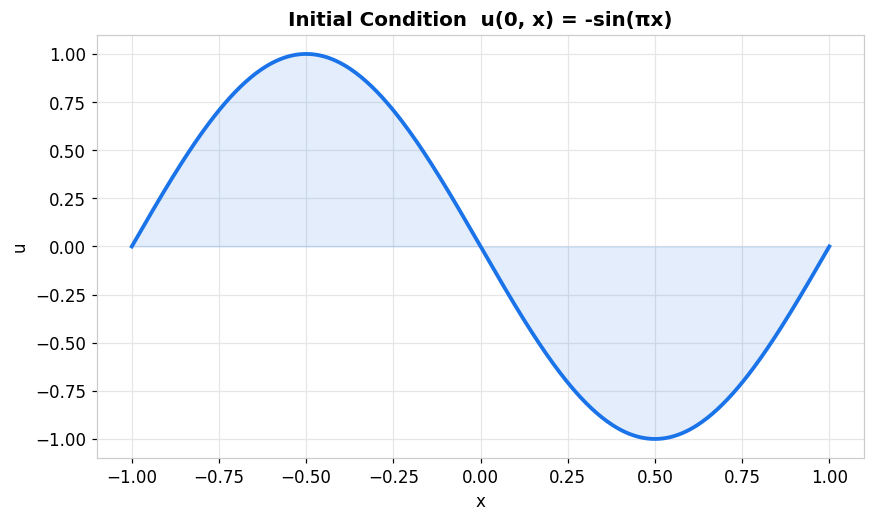

In [2]:
from pinnlab.solvers.raissi_improved import BurgersConfig

cfg = BurgersConfig()                       # domain + physical parameters
print(f"Time domain   t in [{cfg.tmin}, {cfg.tmax}]")
print(f"Space domain  x in [{cfg.xmin}, {cfg.xmax}]")
print(f"Viscosity     nu = {cfg.nu:.5f}  (= 0.01/pi)")

# Visualise the initial condition u(0, x) = -sin(pi x)
x = np.linspace(cfg.xmin, cfg.xmax, 400)
fig, ax = plt.subplots()
ax.plot(x, -np.sin(np.pi * x), color=ACCENT, lw=2.5)
ax.fill_between(x, -np.sin(np.pi * x), color=ACCENT, alpha=0.12)
ax.set(title="Initial Condition  u(0, x) = -sin(πx)", xlabel="x", ylabel="u")
plt.show()

<a id="model"></a>

## 5 · Building the Network

We use a small fully-connected network (`MLP`) with `tanh` activations — smooth activations are important because the PDE needs well-behaved second derivatives. The `ContinuousPINN` solver wires the network to the Burgers residual.

In [3]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import ContinuousPINN, burgers_residual

model = MLP(in_dim=2, hidden_layers=5, width=40, out_dim=1)   # inputs (t, x) -> u
pinn = ContinuousPINN(model=model, device=DEVICE,
                      pde_residual_fn=burgers_residual, cfg_burgers=cfg)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=40, bias=True)
    (9): Tanh()
    (10): Linear(in_features=40, out_features=1, bias=True)
  )
)

Trainable parameters: 6,721


<a id="train"></a>

## 6 · Training

Training proceeds in two stages handled by the solver: **Adam** for robust global progress, followed by a short **L-BFGS** polish — a quasi-Newton optimiser that excels at the final high-accuracy refinement of PINNs.

In [4]:
from pinnlab.solvers.raissi_improved import TrainConfig
import time

tcfg = TrainConfig(
    n_u0=200,        # initial-condition points
    n_bc=100,        # boundary-condition points
    n_f=1_500,       # PDE collocation points
    lr=1e-3,
    adam_steps=2_500,
    lbfgs_max_iter=50,
    seed=SEED,
    track_losses=True,
)

# weights = (IC, BC, PDE): up-weighting the initial condition keeps the
# network anchored to u(0, x) = -sin(pi x) while it learns the dynamics.
t0 = time.time()
history = pinn.train(tcfg, weights=(10.0, 1.0, 1.0))
print(f"Training finished in {time.time() - t0:.1f} s")
print(f"Final total loss : {history['total'][-1]:.3e}")
for k in ("pde", "ic", "bc"):
    print(f"  {k.upper():3s} loss      : {history[k][-1]:.3e}")

Training finished in 53.9 s
Final total loss : 7.491e-02
  PDE loss      : 5.366e-02
  IC  loss      : 2.111e-03
  BC  loss      : 1.455e-04


<a id="dynamics"></a>

## 7 · Training Dynamics

Each loss component should fall steadily. Plotting them on a log scale reveals how the optimiser balances fitting the data (IC/BC) against obeying the PDE.

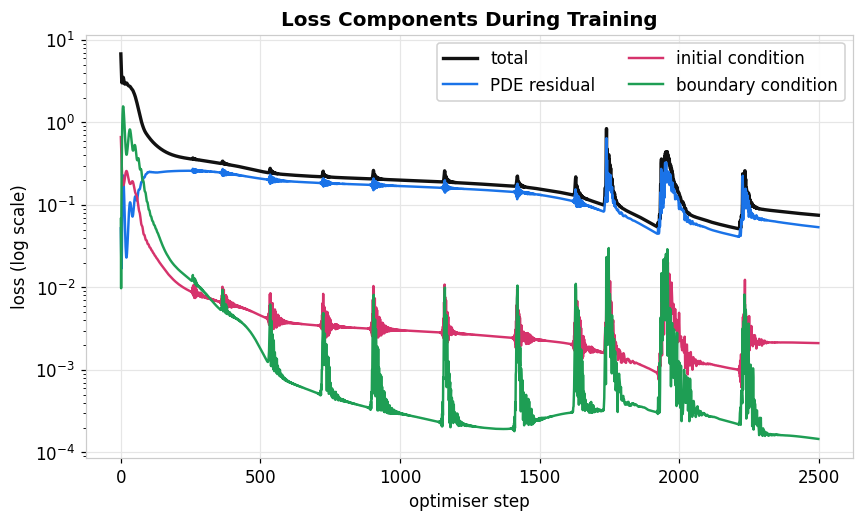

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history["total"], color="#111", lw=2.2, label="total")
ax.plot(history["pde"],   color=ACCENT,  lw=1.6, label="PDE residual")
ax.plot(history["ic"],    color=ACCENT2, lw=1.6, label="initial condition")
ax.plot(history["bc"],    color=ACCENT3, lw=1.6, label="boundary condition")
ax.set_yscale("log")
ax.set(title="Loss Components During Training", xlabel="optimiser step", ylabel="loss (log scale)")
ax.legend(ncol=2)
plt.show()

<a id="solution"></a>

## 8 · The Learned Solution

We evaluate $u_\theta(t,x)$ on a fine $t\times x$ grid and render the full space–time field. The diagonal dark/bright boundary is the **steepening front**.

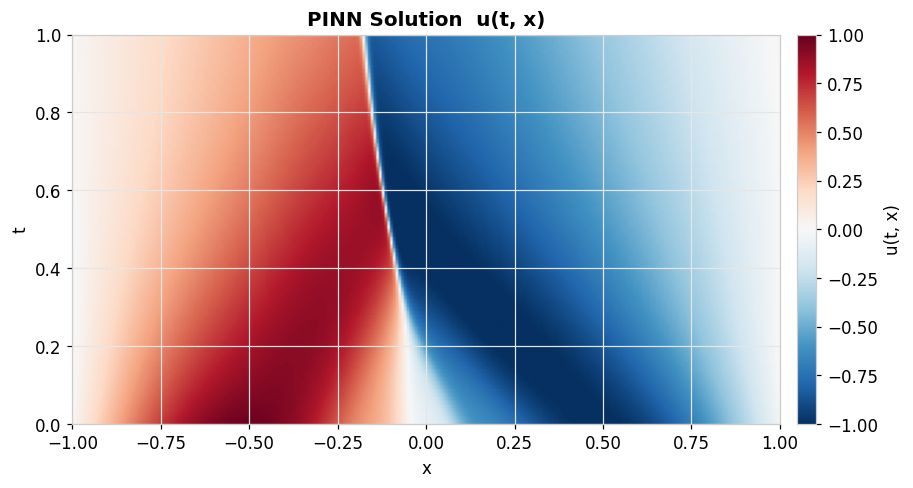

In [6]:
nt, nx = 100, 256
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
U = pinn.predict(TT, XX)                      # shape (nt, nx)

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(U, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(title="PINN Solution  u(t, x)", xlabel="x", ylabel="t")
cbar = fig.colorbar(im, ax=ax, pad=0.02); cbar.set_label("u(t, x)")
plt.show()

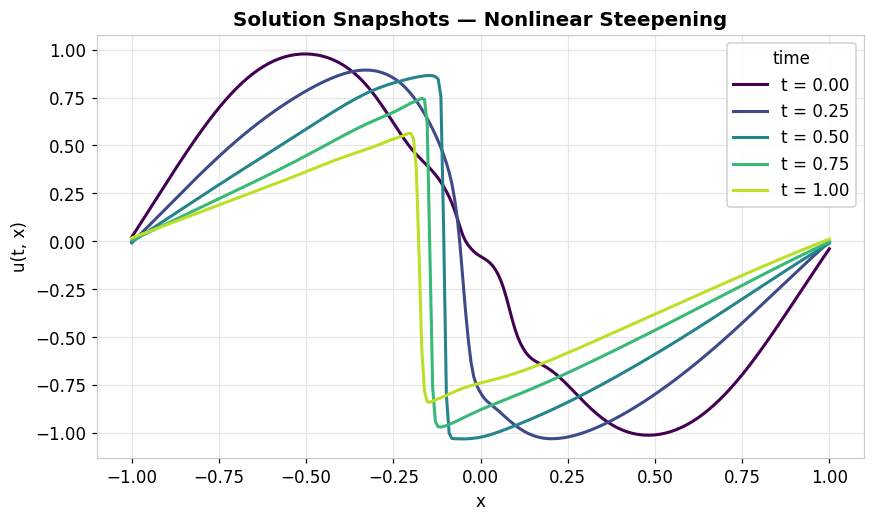

In [7]:
# Snapshots in time: watch the smooth sine wave fold into a sharp front
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, 5))
for t_snap, col in zip([0.0, 0.25, 0.5, 0.75, 1.0], colors):
    idx = np.argmin(np.abs(t_grid - t_snap))
    ax.plot(x_grid, U[idx], color=col, lw=2, label=f"t = {t_snap:.2f}")
ax.set(title="Solution Snapshots — Nonlinear Steepening", xlabel="x", ylabel="u(t, x)")
ax.legend(title="time")
plt.show()

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Notice how the profile near <code>x = 0</code> grows steeper as <code>t</code> increases. That sharpening gradient is the viscous shock — and reproducing it is exactly what makes Burgers a meaningful benchmark.
</div>

<a id="validate"></a>

## 9 · Validating the Physics

Without a labelled ground-truth solution, we validate a PINN the principled way: does it satisfy the conditions we imposed? We check the **initial condition** and **boundary conditions** quantitatively with the library's metrics utility.

In [8]:
from pinnlab.utils.metrics import compute_error_metrics

# --- Initial condition: u(0, x) should equal -sin(pi x) exactly ---
xx = np.linspace(cfg.xmin, cfg.xmax, 400, dtype=np.float32)
u0_pred = pinn.predict(np.zeros_like(xx), xx)            # same shape as input (1D)
u0_true = -np.sin(np.pi * xx)
ic = compute_error_metrics(u0_pred, u0_true)

# --- Boundary condition: u(t, +/-1) should equal 0 ---
tt = np.linspace(cfg.tmin, cfg.tmax, 200, dtype=np.float32)
u_left  = pinn.predict(tt, np.full_like(tt, cfg.xmin))
u_right = pinn.predict(tt, np.full_like(tt, cfg.xmax))
ub = np.concatenate([u_left, u_right])

print("Initial-condition fit  u(0,x) vs -sin(pi x)")
print(f"   MAE        : {ic.mae:.3e}")
print(f"   RMSE       : {ic.rmse:.3e}")
print(f"   max error  : {ic.max_error:.3e}")
print(f"   R^2        : {ic.r2_score:.5f}")
print(f"\nBoundary-condition fit  |u(t,+/-1)|  mean = {np.abs(ub).mean():.3e},  max = {np.abs(ub).max():.3e}")

Initial-condition fit  u(0,x) vs -sin(pi x)
   MAE        : 3.596e-02
   RMSE       : 5.390e-02
   max error  : 1.846e-01
   R^2        : 0.99413

Boundary-condition fit  |u(t,+/-1)|  mean = 7.424e-03,  max = 3.924e-02


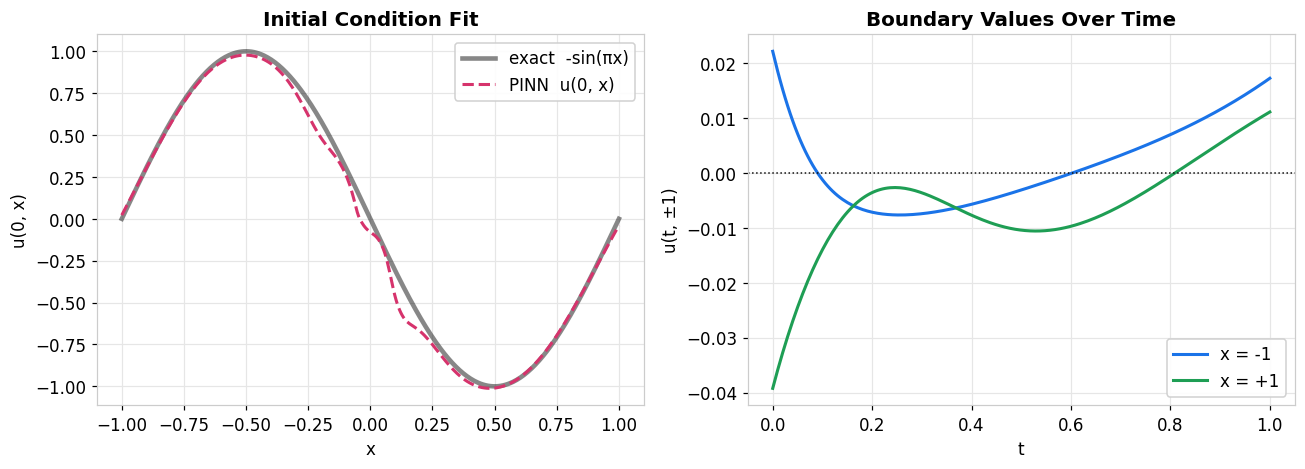

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(xx, u0_true, color="#111", lw=3, alpha=0.5, label="exact  -sin(πx)")
axes[0].plot(xx, u0_pred, color=ACCENT2, lw=2, ls="--", label="PINN  u(0, x)")
axes[0].set(title="Initial Condition Fit", xlabel="x", ylabel="u(0, x)"); axes[0].legend()

axes[1].plot(tt, u_left,  color=ACCENT,  lw=2, label="x = -1")
axes[1].plot(tt, u_right, color=ACCENT3, lw=2, label="x = +1")
axes[1].axhline(0, color="#111", lw=1, ls=":")
axes[1].set(title="Boundary Values Over Time", xlabel="t", ylabel="u(t, ±1)"); axes[1].legend()
plt.tight_layout(); plt.show()

<a id="residual"></a>

## 10 · The PDE Residual

The ultimate physics check: how close is $u_t + u\,u_x - \nu\,u_{xx}$ to zero across the whole domain? We compute it with automatic differentiation on the trained network.

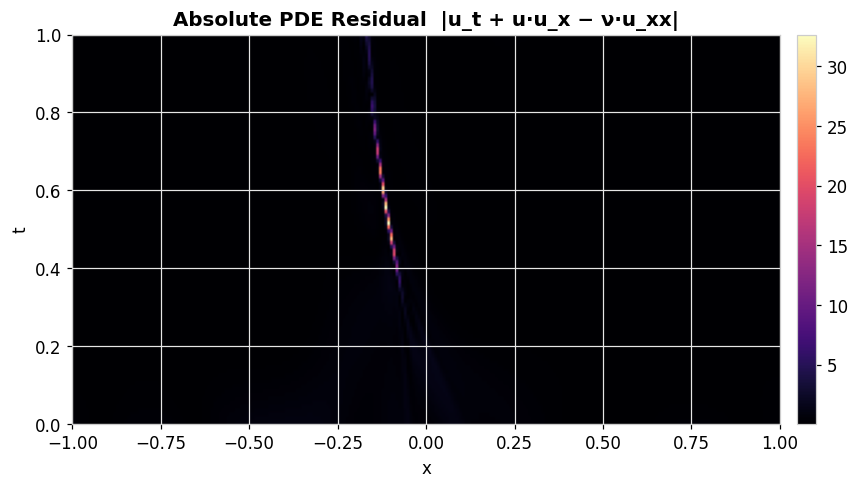

Mean |residual| : 1.446e-01
Max  |residual| : 3.267e+01   (largest along the steep front, as expected)


In [10]:
# Evaluate the Burgers residual on the full grid via autograd
t_t = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=DEVICE, requires_grad=True)
x_t = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=DEVICE, requires_grad=True)
res = burgers_residual(model.to(DEVICE), t_t, x_t, cfg.nu)
res = res.detach().cpu().numpy().reshape(nt, nx)

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(np.abs(res), extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="magma")
ax.set(title="Absolute PDE Residual  |u_t + u·u_x − ν·u_xx|", xlabel="x", ylabel="t")
fig.colorbar(im, ax=ax, pad=0.02)
plt.show()

print(f"Mean |residual| : {np.abs(res).mean():.3e}")
print(f"Max  |residual| : {np.abs(res).max():.3e}   (largest along the steep front, as expected)")

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> The residual is smallest in smooth regions and largest along the front, where derivatives are huge. Pushing it lower there is exactly what adaptive sampling and longer training buy you — see the <code>benchmarks/</code> notebooks.
</div>

<a id="takeaways"></a>

## 11 · Key Takeaways

- A PINN turns **solving a PDE into minimising a loss** built from the equation's residual plus its
  initial/boundary conditions — no mesh and no labelled solution data required.
- `tanh` networks + automatic differentiation give exact, smooth derivatives for the physics loss.
- A two-stage **Adam → L-BFGS** schedule is a reliable recipe for PINN accuracy.
- We validated the result *physically*: tight IC/BC fit and a small PDE residual everywhere, with the
  expected nonlinear steepening near `x = 0`.

**Where to go next:** `basic/02_allen_cahn` (a custom residual), `advanced/03_inverse_problems`
(recover `ν` from data), and `benchmarks/01_active_learning_comparison` (smarter collocation sampling).

### 📚 References

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks*. Journal of Computational Physics, 378, 686–707.
2. Basdevant, C. et al. (1986). *Spectral and finite difference solutions of the Burgers equation*. Computers & Fluids, 14(1), 23–41.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>